In [2]:
import xarray as xr
import pandas as pd
import numpy as np
import cftime
import cf_xarray
import warnings
warnings.filterwarnings("ignore")

In [3]:
import ecubevis as ecv

Task1: Load GFDL_SSP585 (ds_S1) & GFDL_Historical (ds_H) (100km) regridded as Model Future and Model History & ERA5 Upscaled (100km) (dsE) as reference # We keep the reference time period (1985-2014) for correcting bias. We created a folder for storing reference data, biased data and finally bias corredted data using this path "/glade/work/mbadhan/Bias_Correction_100km_GFDL_using_ERA5_1985_2014/Tmin/GFDL_Historical/" (for future work)

# Load Data

In [4]:
#load GFDL_100km Historical Data (ds_H) & GFDL_100km SSP585 (ds_S1) & ERA5 Upscaled (100km) (dsL) as reference # We keep the reference time period same (1985-2014) for correcting bias
ds_H = xr.open_dataset(r'/glade/work/mbadhan/Bias_Correction_100km_GFDL_using_ERA5_1985_2014/Tmin/GFDL_Historical/tas_GFDL_Tmin_Daily_hist_tarreg_1985-2014.nc') #CMIP6_Historical(1985-2014)_100km Regridded
ds_S1 = xr.open_dataset(r'/glade/work/mbadhan/Bias_Correction_100km_GFDL_using_ERA5_1985_2014/Tmin/GFDL_Historical/tas_GFDL_Tmin_Daily_SSP585_tarreg_1985-2014.nc') #CMIP6_SSP585(2070-2099)_100km Regridded
dsE = xr.open_dataset(r'/glade/work/mbadhan/Bias_Correction_100km_GFDL_using_ERA5_1985_2014/Tmin/GFDL_Historical/tmin_daily_era5_tarreg_100km_noleap_85_14.nc') #ERA5_Daily_Minimum_Temperature(1985-2014)

In [4]:
ds_H 

<xarray.Dataset>
Dimensions:    (time: 10950, bnds: 2, lon: 15, lat: 10)
Coordinates:
  * time       (time) object 1985-01-01 10:30:00 ... 2014-12-31 10:30:00
  * lon        (lon) float64 -78.62 -77.62 -76.62 ... -66.62 -65.62 -64.62
  * lat        (lat) float64 45.62 44.62 43.62 42.62 ... 39.62 38.62 37.62 36.62
    height     float64 ...
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object ...
    tas        (time, lat, lon) float32 ...
Attributes: (12/48)
    CDI:                    Climate Data Interface version 1.9.9rc1 (https://...
    history:                Tue Sep 05 01:50:14 2023: cdo remapbil,100km_res_...
    source:                 GFDL-ESM4 (2018):\natmos: GFDL-AM4.1 (Cubed-spher...
    institution:            National Oceanic and Atmospheric Administration, ...
    Conventions:            CF-1.7 CMIP-6.0 UGRID-1.0
    external_variables:     areacella
    ...                     ...
    tracking_id:            hdl:21.14100/e6717347-cdd0-4b7c-abb2-fe006fabae20
    variable_id:            tas
    variant_info:           N/A
    references:             see further_info_url attribute
    variant_label:          r1i1p1f1
    CDO:                    Climate Data Operators version 1.9.9rc1 (https://...

In [5]:
ds_S1

<xarray.Dataset>
Dimensions:    (time: 10950, bnds: 2, lon: 15, lat: 10)
Coordinates:
  * time       (time) object 2070-01-01 10:30:00 ... 2099-12-31 10:30:00
  * lon        (lon) float64 -78.62 -77.62 -76.62 ... -66.62 -65.62 -64.62
  * lat        (lat) float64 45.62 44.62 43.62 42.62 ... 39.62 38.62 37.62 36.62
    height     float64 ...
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object ...
    tas        (time, lat, lon) float32 ...
Attributes: (12/48)
    CDI:                    Climate Data Interface version 1.9.9rc1 (https://...
    history:                Tue Sep 05 14:31:41 2023: cdo remapbil,100km_res_...
    source:                 GFDL-ESM4 (2018):\natmos: GFDL-AM4.1 (Cubed-spher...
    institution:            National Oceanic and Atmospheric Administration, ...
    Conventions:            CF-1.7 CMIP-6.0 UGRID-1.0
    external_variables:     areacella
    ...                     ...
    tracking_id:            hdl:21.14100/6c6589d0-c5d8-441b-a99c-708964de2568
    variable_id:            tas
    variant_info:           N/A
    references:             see further_info_url attribute
    variant_label:          r1i1p1f1
    CDO:                    Climate Data Operators version 1.9.9rc1 (https://...

In [6]:
dsE

<xarray.Dataset>
Dimensions:    (time: 10950, bnds: 2, lon: 15, lat: 10)
Coordinates:
  * time       (time) datetime64[ns] 1985-01-01T11:00:00 ... 2014-12-31T11:00:00
  * lon        (lon) float64 -78.62 -77.62 -76.62 ... -66.62 -65.62 -64.62
  * lat        (lat) float64 45.62 44.62 43.62 42.62 ... 39.62 38.62 37.62 36.62
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] ...
    t2m        (time, lat, lon) float32 ...
Attributes:
    CDI:          Climate Data Interface version 1.9.9rc1 (https://mpimet.mpg...
    Conventions:  CF-1.6
    history:      Tue Sep 05 22:03:19 2023: cdo delete,month=2,day=29 tmin_da...
    frequency:    day
    CDO:          Climate Data Operators version 1.9.9rc1 (https://mpimet.mpg...

# Define Functions

In [7]:
def interpolation(df1,df2,target_val,start,end):
    #data1(df1) = cmip6 historic
    #data2(df2) = variable to be interpolated (ERA5)
    val = df2[start]+((target_val-df1[start])*(df2[end]-df2[start])/(df1[end]-df1[start]))      #this is the function for interpolation
    

    return val

In [8]:
def manipulate(data_scaled, df, current_data_var, hist_data_var,cdf):
    
    interpolated_vals = []
    #cdf_val = []
    
    for i in range(len(data_scaled)):
        
        #find the index of closest value 
        start_ind = 0
        end_ind = 0
        
        index = np.abs(df[hist_data_var].values-data_scaled[i]).argmin()
        sign = (df[hist_data_var][index]-data_scaled[i])  #check 0,-  or + val
        
        
        
        try:
            if data_scaled[i] <= df[hist_data_var].max():

                if data_scaled[i] < df[hist_data_var].min():

                    start_ind = len(df)-1
                    end_ind = len(df[df[hist_data_var] > df[hist_data_var][index]])-1
                    
                    interpolated_era5 = interpolation(df[hist_data_var],df[current_data_var],data_scaled[i],start_ind,end_ind)
                    interpolated_vals.append(interpolated_era5)

                #check the indices greater and smaller than the picked number
                elif sign == 0:      # ''df[hist_data_var][index]'' is basically a value at [hist_data_var]=column of a dataframe,[index]=row of a dataframe position
                    #no interpolation needed
                    interpolated_vals.append(df[current_data_var][index])
                            #cdf_val.append(df[cdf][index])


                elif sign > 0:    #Here, [hist_data_var]=column of a dataframe,[index]=row of a dataframe
                    
                    end_ind = index
                    start_ind = len(df) - len(df[df[hist_data_var] < df[hist_data_var][index]])
                    interpolated_era5 = interpolation(df[hist_data_var],df[current_data_var],data_scaled[i],start_ind,end_ind)
                    interpolated_vals.append(interpolated_era5)


                else:

                    start_ind = index
                    end_ind = len(df[df[hist_data_var] > df[hist_data_var][index]])-1
                 
    #                         #interpolated_cdf = interpolation(df[hist_data_var],df[cdf],data_scaled[i],start_ind,end_ind)
                    interpolated_era5 = interpolation(df[hist_data_var],df[current_data_var],data_scaled[i],start_ind,end_ind)
                    interpolated_vals.append(interpolated_era5)
    #                         #cdf_val.append(interpolated_cdf)


            else:
                end_ind = 0
                start_ind = len(df) - len(df[df[hist_data_var] < df[hist_data_var][index]])
                
    #               interpolated_cdf = interpolation(df[hist_data_var],df[cdf],data_scaled[i],start_ind,end_ind)
    #               interpolated_era5 = interpolation(df[cdf],df[current_data_var],interpolated_cdf,start_ind,end_ind)
    #               interpolated_vals.append(interpolated_era5)
    #               cdf_val.append(interpolated_cdf)
                    #interpolated_vals.append(df[current_data_var].max())
                    #cdf_val.append(1)
                    #extrapolate
                interpolated_era5 = interpolation(df[hist_data_var],df[current_data_var],data_scaled[i],start_ind,end_ind)
                interpolated_vals.append(interpolated_era5) 
        
        except:
            print(i,": ", data_scaled[i], df[hist_data_var][index])
            
        #print(data_scaled[i], start_ind,",",end_ind)
            
    return interpolated_vals  #cdf_val

# Create Ordered Dataframe, Monthly Scale Factor Calculations for Everygrid

In [9]:
#Create dataframe with ERA, CMIP6 and future data
#We will order the ERA and CMIP6, future data left as it is
#data1 = ERA netcdf
#data2 = CMIP6 netcdf
#future_data = SSP
def create_df_ordered(data1,data1_var,data2,data2_var,future_data, future_data_var,lat_ind,lon_ind,month):
    
    #create_df(x_array,var,month,lat_ind,lon_ind):

    era_grouped = data1.isel(time = data1.groupby("time.month").groups[month])[data1_var][:,lat_ind,lon_ind]
    hist_grouped = data2.isel(time = data2.groupby("time.month").groups[month])[data2_var][:,lat_ind,lon_ind]
    future = future_data.isel(time = future_data.groupby("time.month").groups[month])[future_data_var][:,lat_ind,lon_ind].values
    
    #sort and unsort future data
    future_numpy = np.array(future)
    ind = np.flip(np.argsort(future_numpy))
    future_sorted = future_numpy[ind]
    
    
    grp_index = future_data.groupby("time.month").groups[month]
    
    era = era_grouped.sortby(era_grouped, ascending=False)
    hist = hist_grouped.sortby(hist_grouped, ascending=False)
    
    size = len(era)
    cdf = [i/size for i in range(size,0,-1)]
    
    df = pd.DataFrame({
        "ERA": era,
        "CMIP6": hist,
        "SSP" : future,
        "SSP_sorted": future_sorted,
        "cdf": cdf
    })

#     mean_cmip = df.CMIP6.mean()
#     mean_ssp = df.SSP.mean()
    from numpy import inf
    
    difference = df.SSP_sorted.values-df.CMIP6.values
    difference_corrected = np.nan_to_num(difference,nan=0, posinf=0, neginf=0)
    
    #store ratio
    difference = np.zeros(len(difference_corrected))
    difference[ind] = difference_corrected
    
    df["difference"] = difference
    #values smaller than 0.0001 replaced by zero
    df.loc[df["SSP"] < 0.0002, ["SSP","difference"]] = 0
    
    df["SSP_Scaled"] = df["SSP"]-df["difference"]
    df["SSP_Scaled"].replace([np.inf,-np.inf,np.nan],0,inplace=True)
                             
    future_scaled = df["SSP_Scaled"].values
    
    
    #interpolation
    inter_data = manipulate(future_scaled,df,"ERA","CMIP6","cdf")
    

    scaled_data[grp_index,lat_ind,lon_ind] = future_scaled
    data[grp_index,lat_ind,lon_ind] = inter_data   #index for month(First Year Jan 0-30, then Second Year Jan 366-396,...)
    diff[grp_index,lat_ind,lon_ind] = df["difference"].values
   
    return df

In [10]:
#numpy array for storing ratios
diff = np.zeros([10950,10,15])
data = np.zeros([10950,10,15])
scaled_data = np.zeros([10950,10,15])
for i in range(10):
    for j in range(15):
        for k in range(1,13):
            create_df_ordered(dsE,"t2m",ds_H,"tas",ds_S1,"tas",i,j,k)
    print("processed: ",i)

processed:  0
processed:  1
processed:  2
processed:  3
processed:  4
processed:  5
processed:  6
processed:  7
processed:  8
processed:  9


In [23]:
ds_S1["Bias_corrected_t2m"] = (['time', 'lat', 'lon'],  data) #save the file as netcdf

In [24]:
ds_S1

<xarray.Dataset>
Dimensions:             (time: 10950, bnds: 2, lon: 15, lat: 10)
Coordinates:
  * time                (time) object 2070-01-01 10:30:00 ... 2099-12-31 10:3...
  * lon                 (lon) float64 -78.62 -77.62 -76.62 ... -65.62 -64.62
  * lat                 (lat) float64 45.62 44.62 43.62 ... 38.62 37.62 36.62
    height              float64 ...
Dimensions without coordinates: bnds
Data variables:
    time_bnds           (time, bnds) object ...
    tas                 (time, lat, lon) float32 ...
    Bias_corrected_t2m  (time, lat, lon) float64 255.5 257.2 ... 286.3 286.6
Attributes: (12/48)
    CDI:                    Climate Data Interface version 1.9.9rc1 (https://...
    history:                Tue Sep 05 14:31:41 2023: cdo remapbil,100km_res_...
    source:                 GFDL-ESM4 (2018):\natmos: GFDL-AM4.1 (Cubed-spher...
    institution:            National Oceanic and Atmospheric Administration, ...
    Conventions:            CF-1.7 CMIP-6.0 UGRID-1.0
    external_variables:     areacella
    ...                     ...
    tracking_id:            hdl:21.14100/6c6589d0-c5d8-441b-a99c-708964de2568
    variable_id:            tas
    variant_info:           N/A
    references:             see further_info_url attribute
    variant_label:          r1i1p1f1
    CDO:                    Climate Data Operators version 1.9.9rc1 (https://...

In [25]:
ds_S1["Scaled_t2m"] = (['time', 'lat', 'lon'], scaled_data)

In [26]:
ds_S1["Difference"] = (['time', 'lat', 'lon'], diff)

In [27]:
ds_S1

<xarray.Dataset>
Dimensions:             (time: 10950, bnds: 2, lon: 15, lat: 10)
Coordinates:
  * time                (time) object 2070-01-01 10:30:00 ... 2099-12-31 10:3...
  * lon                 (lon) float64 -78.62 -77.62 -76.62 ... -65.62 -64.62
  * lat                 (lat) float64 45.62 44.62 43.62 ... 38.62 37.62 36.62
    height              float64 ...
Dimensions without coordinates: bnds
Data variables:
    time_bnds           (time, bnds) object ...
    tas                 (time, lat, lon) float32 ...
    Bias_corrected_t2m  (time, lat, lon) float64 255.5 257.2 ... 286.3 286.6
    Scaled_t2m          (time, lat, lon) float64 255.9 257.3 ... 285.0 285.3
    Difference          (time, lat, lon) float64 9.885 9.528 ... 2.444 2.333
Attributes: (12/48)
    CDI:                    Climate Data Interface version 1.9.9rc1 (https://...
    history:                Tue Sep 05 14:31:41 2023: cdo remapbil,100km_res_...
    source:                 GFDL-ESM4 (2018):\natmos: GFDL-AM4.1 (Cubed-spher...
    institution:            National Oceanic and Atmospheric Administration, ...
    Conventions:            CF-1.7 CMIP-6.0 UGRID-1.0
    external_variables:     areacella
    ...                     ...
    tracking_id:            hdl:21.14100/6c6589d0-c5d8-441b-a99c-708964de2568
    variable_id:            tas
    variant_info:           N/A
    references:             see further_info_url attribute
    variant_label:          r1i1p1f1
    CDO:                    Climate Data Operators version 1.9.9rc1 (https://...

# Creating NetCDF

In [28]:
new_filename_1 = r'/glade/work/mbadhan/Bias_Correction_100km_GFDL_using_ERA5_1985_2014/Tmin_Diff/Bias_Corrected/Tmin_GFDL_SSP585_100km_Bias_Corrected_Diff_2070_2099.nc'
print ('saving to ', new_filename_1)
ds_S1.to_netcdf(path=new_filename_1)
print ('finished saving')

saving to  /glade/work/mbadhan/Bias_Correction_100km_GFDL_using_ERA5_1985_2014/Tmin_Diff/Bias_Corrected/Tmin_GFDL_SSP585_100km_Bias_Corrected_Diff_1985_2014.nc
finished saving


In [6]:
corrected_ds_S1=xr.open_dataset(r'/glade/work/mbadhan/Bias_Correction_100km_GFDL_using_ERA5_1985_2014/Tmin_Diff/Bias_Corrected/Tmin_GFDL_SSP585_100km_Bias_Corrected_Diff_2070_2099.nc')

In [7]:
corrected_ds_S1

<xarray.Dataset>
Dimensions:             (time: 10950, bnds: 2, lon: 15, lat: 10)
Coordinates:
  * time                (time) object 2070-01-01 10:30:00 ... 2099-12-31 10:3...
  * lon                 (lon) float64 -78.62 -77.62 -76.62 ... -65.62 -64.62
  * lat                 (lat) float64 45.62 44.62 43.62 ... 38.62 37.62 36.62
    height              float64 ...
Dimensions without coordinates: bnds
Data variables:
    time_bnds           (time, bnds) object ...
    tas                 (time, lat, lon) float32 ...
    Bias_corrected_t2m  (time, lat, lon) float64 ...
    Scaled_t2m          (time, lat, lon) float64 ...
    Difference          (time, lat, lon) float64 ...
Attributes: (12/48)
    CDI:                    Climate Data Interface version 1.9.9rc1 (https://...
    history:                Tue Sep 05 14:31:41 2023: cdo remapbil,100km_res_...
    source:                 GFDL-ESM4 (2018):\natmos: GFDL-AM4.1 (Cubed-spher...
    institution:            National Oceanic and Atmospheric Administration, ...
    Conventions:            CF-1.7 CMIP-6.0 UGRID-1.0
    external_variables:     areacella
    ...                     ...
    tracking_id:            hdl:21.14100/6c6589d0-c5d8-441b-a99c-708964de2568
    variable_id:            tas
    variant_info:           N/A
    references:             see further_info_url attribute
    variant_label:          r1i1p1f1
    CDO:                    Climate Data Operators version 1.9.9rc1 (https://...

# Subplot for 12 Months

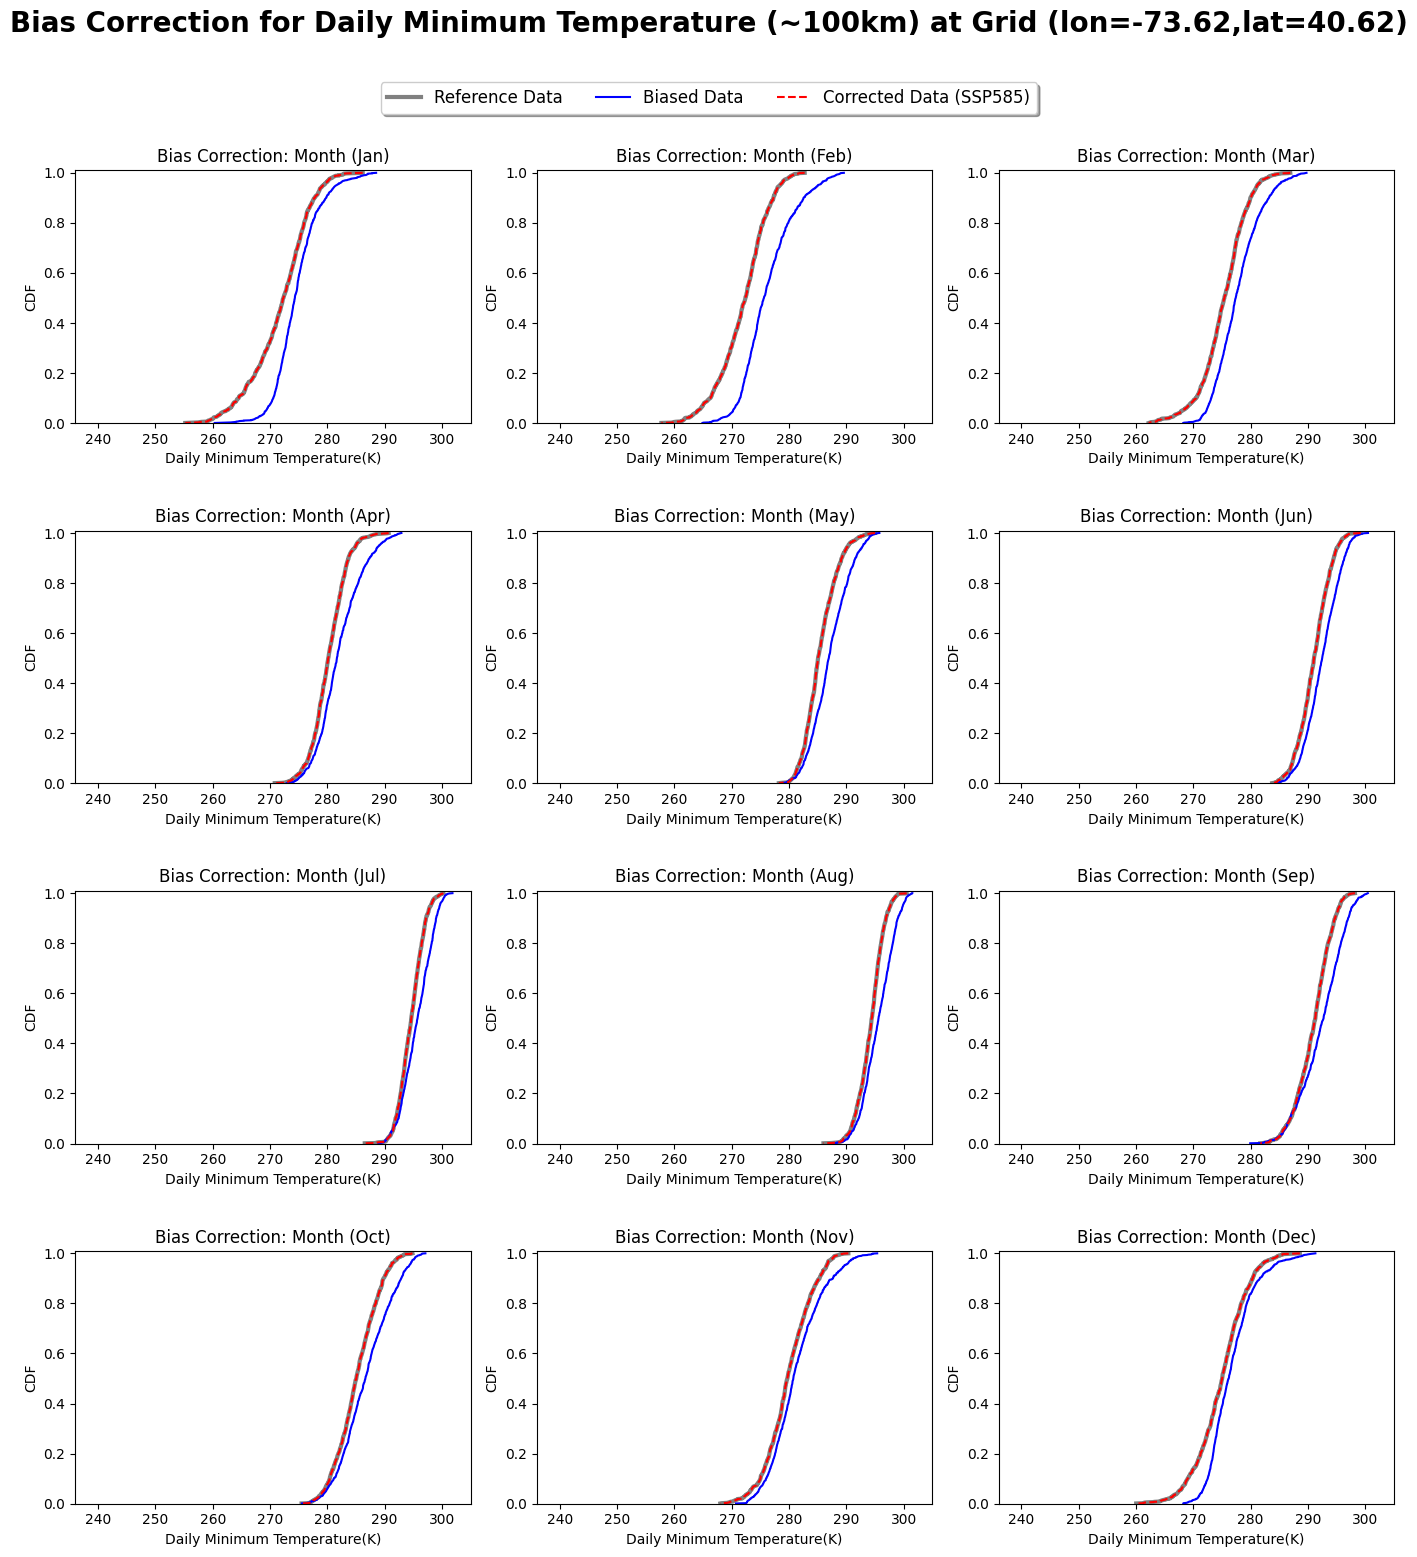

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import calendar


# Define your functions for creating dataframes here

def create_df(x_array, var, month, lat_ind, lon_ind):
    groups = x_array.groupby("time.month").groups
    filtered = x_array.isel(time=groups[month])
    data = filtered[var][:,lat_ind,lon_ind]
    time = filtered.time

    
    df = pd.DataFrame({
        "Date": time,
        "Min_Temp" : data})
    
    return df

def create_df_plot(data1, data1_var, data2, data2_var, data3, data3_var1, data3_var2, data3_var3, col1, col2, col3, col4, col5, col6, lat_ind, lon_ind, month):
    era = create_df(data1,data1_var,month,lat_ind,lon_ind)
    hist = create_df(data2,data2_var,month,lat_ind,lon_ind)
    s1 = create_df(data3,data3_var1,month,lat_ind,lon_ind)
    s1_Scaled = create_df(data3,data3_var2,month,lat_ind,lon_ind)
    s1_CR= create_df(data3,data3_var3,month,lat_ind,lon_ind)
    
    
    dt1 = era.sort_values("Min_Temp", ascending = False).Min_Temp.values
    dt2 = hist.sort_values("Min_Temp", ascending = False).Min_Temp.values
    dt3 = s1.sort_values("Min_Temp", ascending = False).Min_Temp.values
    dt4 = s1_Scaled.sort_values("Min_Temp", ascending = False).Min_Temp.values
    dt5 = s1_CR.sort_values("Min_Temp", ascending = False).Min_Temp.values
    
    size = len(dt1)
    cdf = [i/size for i in range(size,0,-1)]
    
    df = pd.DataFrame({
        col1: dt1,
        col2: dt2,
        col3: dt3,
        col4: dt4,
        col5: dt5,
        col6: cdf
    })
    
    return df

# Loop through each month and create subplots
fig, axs = plt.subplots(4, 3, figsize=(14, 16))

# Define a list of month names
month_names = [calendar.month_abbr[i] for i in range(1, 13)]  # Use month_abbr for abbreviated month names (e.g., Jan, Feb)

legend_handles = []  # List to collect legend handles
legend_labels = []   # List to collect legend labels

for month in range(1, 13):
    # Get the data for the current month
    dataset_plt = create_df_plot(dsE,"t2m",ds_H, "tas", corrected_ds_S1,"tas", "Scaled_t2m","Bias_corrected_t2m","ERA5","CMIP6_H","SSP585_Original","SSP585_Scaled","Corrected_SSP585","CDF",5,5,month)
    
    frame_plt = pd.DataFrame({
        "ERA5": dataset_plt.ERA5.values,
        "CMIP6_Hist":  dataset_plt.CMIP6_H.values,
        "SSP_585_Original": dataset_plt.SSP585_Original.values,
        "SSP_585_Scaled": dataset_plt.SSP585_Scaled.values,
        "SSP_585_Corrected": dataset_plt.Corrected_SSP585.values,
        "CDF": dataset_plt.CDF.values
    })

    # Calculate subplot position
    row = (month - 1) // 3
    col = (month - 1) % 3
    
    # Plot on the current subplot
    ax = axs[row, col]
    ref_line,= ax.plot(frame_plt["ERA5"], frame_plt["CDF"], linewidth=3, color='gray', label="Reference Data")
    biased_line,= ax.plot(frame_plt["SSP_585_Original"], frame_plt["CDF"], color='blue', label="Biased Data")
    corrected_line,= ax.plot(frame_plt["SSP_585_Corrected"], frame_plt["CDF"], linestyle='--', color='red', label="Corrected Data (SSP585)")
    ax.set_xlim(236, 305)  # x-axis limits
    ax.set_ylim(0, 1.01)   # y-axis limits
    ax.set_title(f"Bias Correction: Month ({month_names[month - 1]})")  # Use month
    ax.set_xlabel("Daily Minimum Temperature(K)")
    ax.set_ylabel("CDF")
    #ax.legend()

# Collect legend handles and labels
    if month == 1:  # Only collect legend handles and labels once
        legend_handles.append(ref_line)
        legend_handles.append(biased_line)
        legend_handles.append(corrected_line)
        legend_labels.append("Reference Data")
        legend_labels.append("Biased Data")
        legend_labels.append("Corrected Data (SSP585)")


# Add an overall title to the plot
plt.suptitle(f"Bias Correction for Daily Minimum Temperature (~100km) at Grid (lon={dsE.lon.values[5]:.2f},lat={dsE.lat.values[5]:.2f})", fontsize=20, fontweight='bold',y=1.0)

# Add legend between subplot title and subplot
fig.legend(legend_handles, legend_labels, loc='upper center', bbox_to_anchor=(0.5, 0.96), fontsize='large',fancybox=True, shadow=True, ncol=3)

# Adjust layout and display the plot with increased vertical spacing between subplots
plt.tight_layout(rect=[0, 0.03, 1, 0.95], h_pad=3.0)  # Adjust the layout to leave space for the shared title and legend

# Specify the file path and save the plot
file_path = r'/glade/work/mbadhan/Plot/Bias_Correction/Tmin_Diff_100km/Bias_Correction_Tmin_100km_w_ERA5_2070_2099.png'

plt.savefig(file_path, dpi=600)

plt.show()


# Plotting

In [32]:
def create_df(x_array,var,month,lat_ind,lon_ind):
    groups = x_array.groupby("time.month").groups
    filtered = x_array.isel(time=groups[month])
    data = filtered[var][:,lat_ind,lon_ind]
    time = filtered.time
    
#    mean = data.mean().values
#    std  = data.std()
    
    #print("mean: ", mean,"standard dev: ",std)
    
    df = pd.DataFrame({
        "Date": time,
        "Min_Temp" : data})
    
    return df

In [33]:
#create dataframe variables organized in descending order
def create_df_plot(data1,data1_var,data2,data2_var,data3,data3_var1,data3_var2,data3_var3,col1,col2,col3,col4,col5,col6,lat_ind,lon_ind,month):
    
    #create_df(x_array,var,month,lat_ind,lon_ind):

    era = create_df(data1,data1_var,month,lat_ind,lon_ind)
    hist = create_df(data2,data2_var,month,lat_ind,lon_ind)
    s1 = create_df(data3,data3_var1,month,lat_ind,lon_ind)
    s1_Scaled = create_df(data3,data3_var2,month,lat_ind,lon_ind)
    s1_CR= create_df(data3,data3_var3,month,lat_ind,lon_ind)
    
    
    dt1 = era.sort_values("Min_Temp", ascending = False).Min_Temp.values
    dt2 = hist.sort_values("Min_Temp", ascending = False).Min_Temp.values
    dt3 = s1.sort_values("Min_Temp", ascending = False).Min_Temp.values
    dt4 = s1_Scaled.sort_values("Min_Temp", ascending = False).Min_Temp.values
    dt5 = s1_CR.sort_values("Min_Temp", ascending = False).Min_Temp.values
    
    size = len(dt1)
    cdf = [i/size for i in range(size,0,-1)]
    
    df = pd.DataFrame({
        col1: dt1,
        col2: dt2,
        col3: dt3,
        col4: dt4,
        col5: dt5,
        col6: cdf
    })
    
    return df

In [34]:
dataset_plt = create_df_plot(dsE,"t2m",ds_H, "tas", corrected_ds_S1,"tas", "Scaled_t2m","Bias_corrected_t2m","ERA5","CMIP6_H","SSP585_Original","SSP585_Scaled","Corrected_SSP585","CDF",5,5,4)

In [35]:
dataset_plt.head(5)

,ERA5,CMIP6_H,SSP585_Original,SSP585_Scaled,Corrected_SSP585,CDF
0,290.693665,290.246277,292.921692,290.246277,290.693665,1.000000
1,290.414978,289.266296,292.665161,289.266296,290.414978,0.998889
2,289.568542,289.250244,292.610718,289.250244,289.568542,0.997778
3,289.036346,288.757202,292.293793,288.757202,289.036346,0.996667
4,288.444427,288.554199,292.267883,288.554199,288.444427,0.995556


In [36]:
dataset_plt.tail(5)

,ERA5,CMIP6_H,SSP585_Original,SSP585_Scaled,Corrected_SSP585,CDF
895,272.870209,268.767670,274.061829,268.767670,272.870209,0.005556
896,272.743134,268.755585,273.719940,268.755585,272.743134,0.004444
897,272.567383,267.593048,273.412903,267.593048,272.567383,0.003333
898,272.061249,265.879791,273.362274,265.879791,272.061249,0.002222
899,270.823273,264.927582,272.927185,264.927582,270.823273,0.001111


In [38]:
import xarray as xr 
# import the matplotlib, which is converted from matplot of MatLab
import matplotlib.pyplot as plt 
import pandas as pd
import glob
import math
import cartopy.crs as ccrs # Python package designed for geospatial data processing in order to produce maps and other geospatial data analyses.
import numpy as np #package with multidimensional array manipulators
# the following section import individual functions from specific packages
from matplotlib import cm # import the cm function
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter #function to add lat/lon labels
from cartopy.util import add_cyclic_point #function to "wrap" the data into a sphere. Aka, the program adds values of 0° longitude next to 360° longitude, and 360° before 0 
from numpy import linspace # function to create evenly spaced numbers over a specified interval.

In [39]:
frame_plt = pd.DataFrame({
    "ERA5": dataset_plt.ERA5.values,
    "CMIP6_Hist":  dataset_plt.CMIP6_H.values,
    "SSP_585_Original": dataset_plt.SSP585_Original.values,
    "SSP_585_Scaled": dataset_plt.SSP585_Scaled.values,
    "SSP_585_Corrected": dataset_plt.Corrected_SSP585.values,
    "CDF": dataset_plt.CDF.values
})

In [40]:
frame_plt.head(5)

,ERA5,CMIP6_Hist,SSP_585_Original,SSP_585_Scaled,SSP_585_Corrected,CDF
0,290.693665,290.246277,292.921692,290.246277,290.693665,1.000000
1,290.414978,289.266296,292.665161,289.266296,290.414978,0.998889
2,289.568542,289.250244,292.610718,289.250244,289.568542,0.997778
3,289.036346,288.757202,292.293793,288.757202,289.036346,0.996667
4,288.444427,288.554199,292.267883,288.554199,288.444427,0.995556


In [41]:
frame_plt.tail(5)

,ERA5,CMIP6_Hist,SSP_585_Original,SSP_585_Scaled,SSP_585_Corrected,CDF
895,272.870209,268.767670,274.061829,268.767670,272.870209,0.005556
896,272.743134,268.755585,273.719940,268.755585,272.743134,0.004444
897,272.567383,267.593048,273.412903,267.593048,272.567383,0.003333
898,272.061249,265.879791,273.362274,265.879791,272.061249,0.002222
899,270.823273,264.927582,272.927185,264.927582,270.823273,0.001111


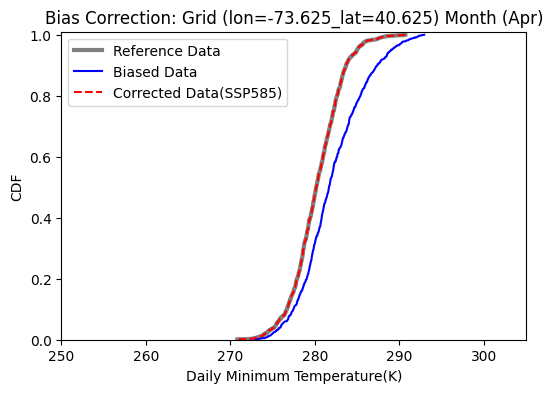

In [42]:
import matplotlib.pyplot as plt 
plt.figure(num=None, figsize=(6, 4),  facecolor='w', edgecolor='k')
        
ax = plt.gca()



check_indexed = frame_plt.set_index('CDF')
plt.plot(check_indexed["ERA5"],check_indexed.index, linewidth=3, color = 'gray',label="Reference Data")
plt.plot(check_indexed["SSP_585_Original"],check_indexed.index, color = 'blue',label="Biased Data")
#plt.plot(check_indexed["CMIP6_Hist"],check_indexed.index, color = 'pink',label="Historical Data")


#check_indexed = check.set_index('inter_cdf')
plt.plot(check_indexed["SSP_585_Corrected"],check_indexed.index,linestyle='--', color = 'red',label="Corrected Data(SSP585)")

plt.xlim(250, 305)  # x-axis limits
plt.ylim(0, 1.01)  # y-axis limits

plt.title("Bias Correction: Grid (lon=-73.625_lat=40.625) Month (Apr)")
plt.xlabel("Daily Minimum Temperature(K)")
plt.ylabel("CDF")
plt.legend()
plt.show()